In [244]:
import os
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from scipy.ndimage import grey_opening, grey_closing

In [2]:
data_dir = 'data'

In [180]:
df_usd_to_inr = pd.read_csv(os.path.join(data_dir, 'usd_to_inr.csv'))
df_rallis = pd.read_csv(os.path.join(data_dir, 'RALLIS.csv'))
df_rallis = df_rallis[['date', 'avg']].rename(columns={'avg': 'price_inr'})

In [228]:
df_inr = df_rallis.merge(df_usd_to_inr, on='date', how='inner')

In [229]:
# check for missing dates
date_range = pd.date_range(start=df_inr['date'].min(), end=df_inr['date'].max())
date_available = pd.to_datetime(df_inr['date'])
missing_dates = date_range.difference(date_available)
print(f'Missing dates: {missing_dates}')

Missing dates: DatetimeIndex(['2008-01-05', '2008-01-06', '2008-01-12', '2008-01-13',
               '2008-01-19', '2008-01-20', '2008-01-26', '2008-01-27',
               '2008-02-02', '2008-02-03',
               ...
               '2026-04-19', '2026-04-25', '2026-04-26', '2026-05-01',
               '2026-05-02', '2026-05-03', '2026-05-09', '2026-05-10',
               '2026-05-16', '2026-05-17'],
              dtype='datetime64[us]', length=2184, freq=None)


In [230]:
# expand df to have all dates, and fill missing price with previous available price
df_inr['date'] = pd.to_datetime(df_inr['date'])
df_inr = df_inr.set_index('date').reindex(date_range).reset_index().rename(columns={'index': 'date'})
df_inr = df_inr.ffill()

In [184]:
df_usd = df_inr.copy()
df_usd['price_usd'] = df_inr['price_inr'] / df_inr['usd_to_inr']
df_usd = df_usd[['date', 'price_usd']]

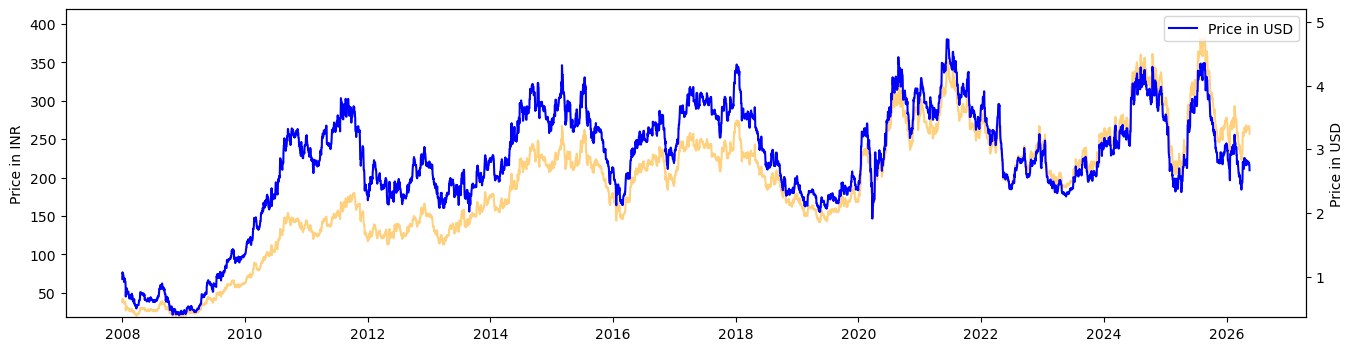

In [185]:
# plot price_inr and price_usd over time in same plot
# use different y-axis for price_inr and price_usd
plt.figure(figsize=(16, 4))
ax1 = plt.gca()
ax2 = ax1.twinx()
ax1.set_ylabel('Price in INR')
ax2.set_ylabel('Price in USD')
ax1.set_ylim(df_inr['price_inr'].min() * 0.9, df_inr['price_inr'].max() * 1.1)
ax2.set_ylim(df_usd['price_usd'].min() * 0.9, df_usd['price_usd'].max() * 1.1)
ax1.plot(df_inr['date'], df_inr['price_inr'], label='Price in INR', color='orange', alpha=0.5)
ax2.plot(df_usd['date'], df_usd['price_usd'], label='Price in USD', color='blue')
plt.xlabel('Year')
plt.legend()
plt.show()

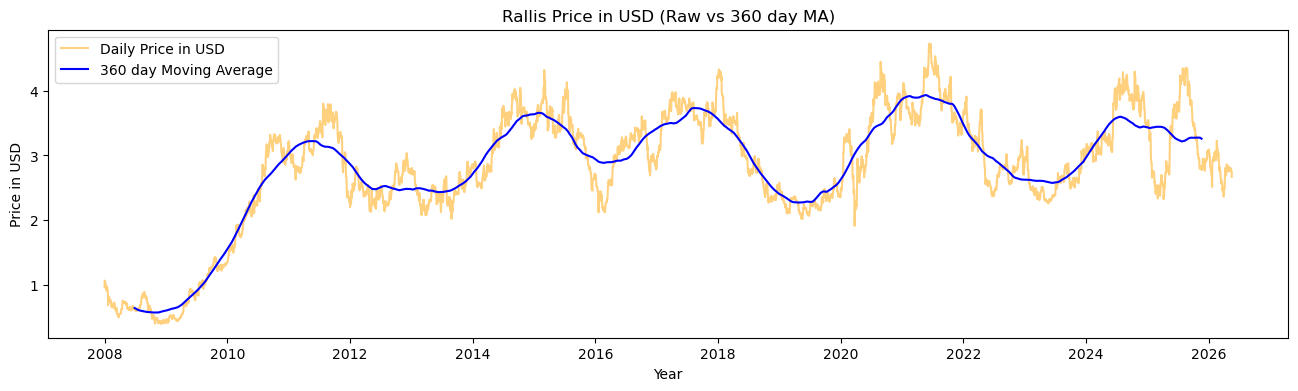

In [186]:
# smoothen the price_usd using 360 day moving average
df_usd['price_usd_smooth'] = df_usd['price_usd'].rolling(window=360).mean()
# adjust lag of moving average by shifting it back by 180 days
df_usd['price_usd_smooth'] = df_usd['price_usd_smooth'].shift(-180)
plt.figure(figsize=(16, 4))
plt.plot(df_usd['date'], df_usd['price_usd'], label='Daily Price in USD', alpha=0.5, color='orange')
plt.plot(df_usd['date'], df_usd['price_usd_smooth'], label='360 day Moving Average', color='blue')
plt.xlabel('Year')
plt.ylabel('Price in USD')
plt.legend()
plt.title('Rallis Price in USD (Raw vs 360 day MA)')
plt.show()

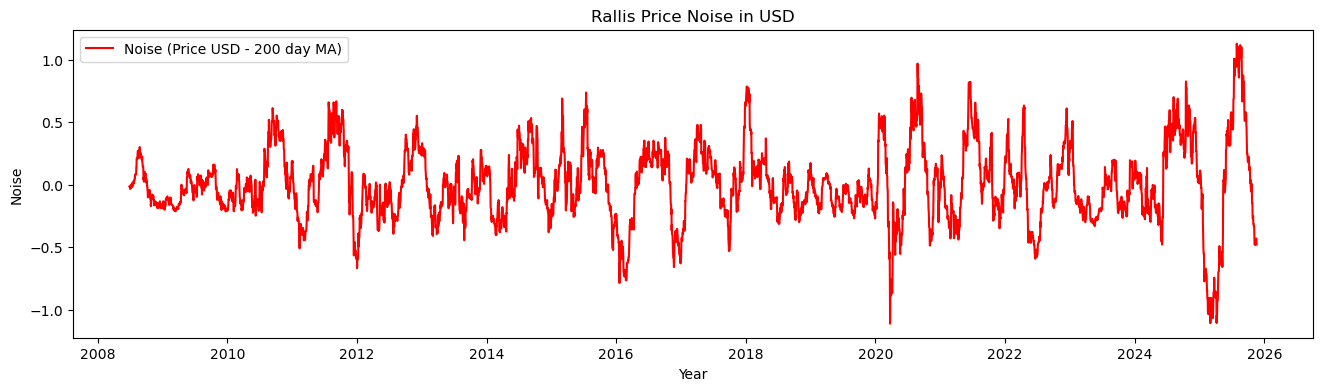

In [187]:
df_usd['noise'] = df_usd['price_usd'] - df_usd['price_usd_smooth']
plt.figure(figsize=(16, 4))
plt.plot(df_usd['date'], df_usd['noise'], label='Noise (Price USD - 200 day MA)', color='red')
plt.xlabel('Year')
plt.ylabel('Noise')
plt.legend()
plt.title('Rallis Price Noise in USD')
plt.show()

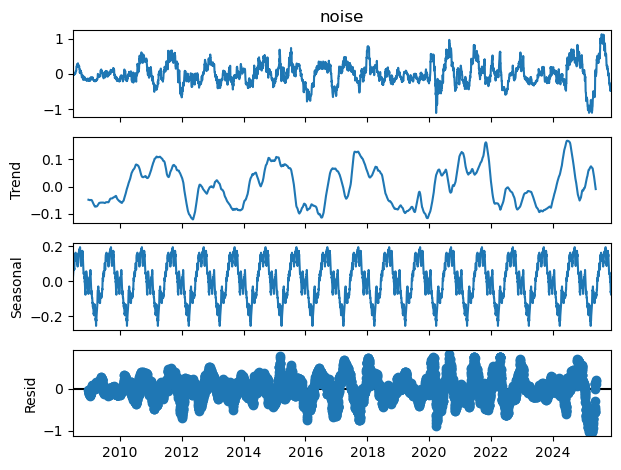

In [188]:
# time series decomposition using statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose
df_usd_ts = df_usd.copy()
df_usd_ts.dropna(inplace=True)
df_usd_ts.set_index('date', inplace=True)
decomposition = seasonal_decompose(df_usd_ts['noise'], model='additive', period=365)
decomposition.plot()
plt.show()

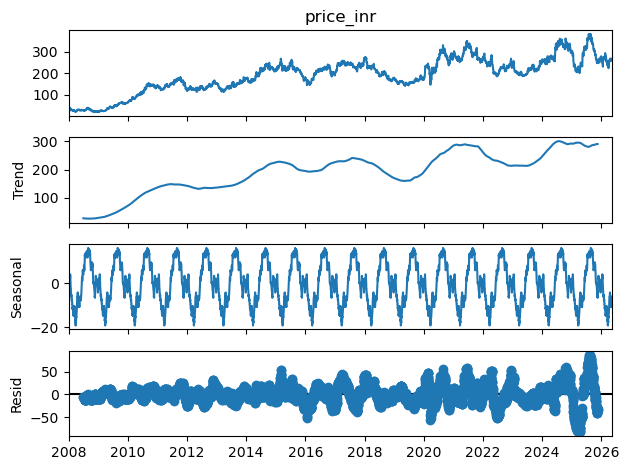

In [189]:
# time series decomposition using statsmodels
df_inr_ts = df_inr.copy()
df_inr_ts.set_index('date', inplace=True)
decomposition = seasonal_decompose(df_inr_ts['price_inr'], model='additive', period=365)
decomposition.plot()
plt.show()

In [190]:
df_inr_ts['trend'] = decomposition.trend
df_inr_ts['seasonal'] = decomposition.seasonal
df_inr_ts.dropna(inplace=True)
df_inr_ts['trend_seasonal'] = df_inr_ts['trend'] + df_inr_ts['seasonal']
df_inr_ts.reset_index(inplace=True)
display(df_inr_ts.head(90))
display(df_inr_ts.tail(90))

,date,price_inr,usd_to_inr,trend,seasonal,trend_seasonal
0,2008-07-01,27.0,43.34,27.463014,4.680212,32.143225
1,2008-07-02,26.0,43.19,27.419178,5.033484,32.452662
2,2008-07-03,26.0,43.29,27.361644,5.609588,32.971231
3,2008-07-04,26.0,43.12,27.306849,5.685082,32.991932
4,2008-07-05,26.0,43.12,27.254795,6.149161,33.403956
...,...,...,...,...,...,...
85,2008-09-24,30.0,46.00,26.109589,10.650075,36.759664
86,2008-09-25,31.0,46.22,26.117808,10.283408,36.401216
87,2008-09-26,31.0,46.56,26.128767,9.140181,35.268948
88,2008-09-27,31.0,46.56,26.136986,8.886148,35.023134


,date,price_inr,usd_to_inr,trend,seasonal,trend_seasonal
6259,2025-08-20,375.0,87.02,283.375342,12.927700,296.303043
6260,2025-08-21,374.0,87.29,283.594521,12.721003,296.315524
6261,2025-08-22,372.0,87.33,283.794521,13.182038,296.976559
6262,2025-08-23,372.0,87.33,283.980822,12.865447,296.846269
6263,2025-08-24,372.0,87.33,284.167123,14.382495,298.549618
...,...,...,...,...,...,...
6344,2025-11-13,251.0,88.82,290.898630,-4.706851,286.191779
6345,2025-11-14,251.0,88.69,290.832877,-6.131965,284.700912
6346,2025-11-15,251.0,88.69,290.767123,-5.779301,284.987822
6347,2025-11-16,251.0,88.69,290.701370,-6.148860,284.552510


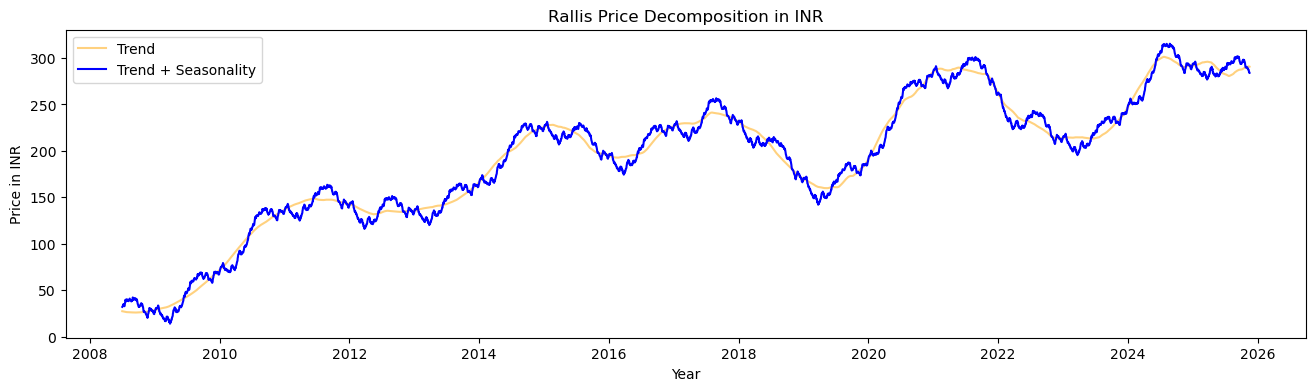

In [191]:
# add trend and seasonality and plot
plt.figure(figsize=(16, 4))
plt.plot(df_inr_ts['date'], df_inr_ts['trend'], label='Trend', alpha=0.5, color='orange')
plt.plot(df_inr_ts['date'], df_inr_ts['trend_seasonal'], label='Trend + Seasonality', color='blue')
plt.xlabel('Year')
plt.ylabel('Price in INR')
plt.legend()
plt.title('Rallis Price Decomposition in INR')
plt.show()

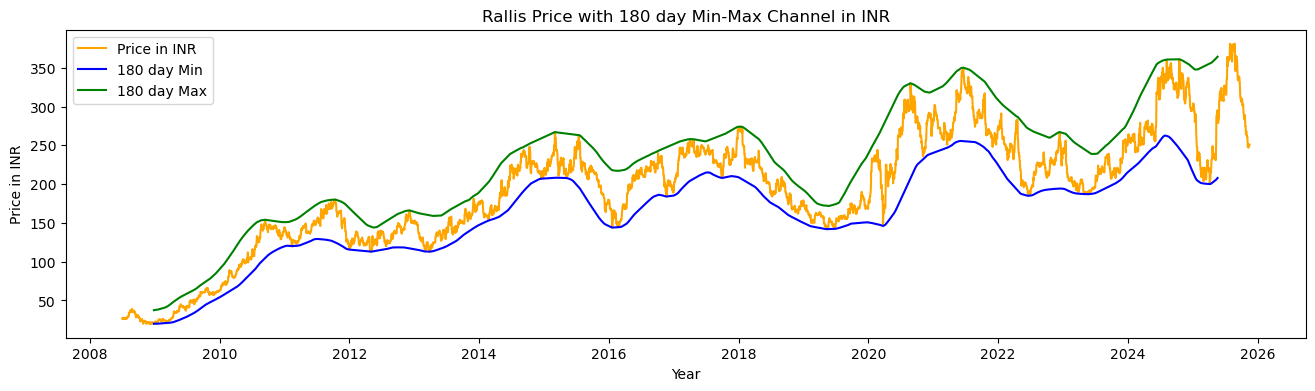

In [192]:
# create a min-max channel for 180 day window
df_inr_ts['price_min'] = df_inr_ts['price_inr'].rolling(window=180).min()
df_inr_ts['price_max'] = df_inr_ts['price_inr'].rolling(window=180).max()
# smooth the min-max channel using moving average
df_inr_ts['price_min'] = df_inr_ts['price_min'].rolling(window=180).mean()
df_inr_ts['price_max'] = df_inr_ts['price_max'].rolling(window=180).mean()
# adjust lag of min-max channel to align with price_inr
# (180 + 180) // 2 = 180
df_inr_ts['price_min'] = df_inr_ts['price_min'].shift(-180)
df_inr_ts['price_max'] = df_inr_ts['price_max'].shift(-180)
plt.figure(figsize=(16, 4))
plt.plot(df_inr_ts['date'], df_inr_ts['price_inr'], label='Price in INR', color='orange')
plt.plot(df_inr_ts['date'], df_inr_ts['price_min'], label='180 day Min', color='blue')
plt.plot(df_inr_ts['date'], df_inr_ts['price_max'], label='180 day Max', color='green')
plt.xlabel('Year')
plt.ylabel('Price in INR')
plt.legend()
plt.title('Rallis Price with 180 day Min-Max Channel in INR')
plt.show()

# Circle Method

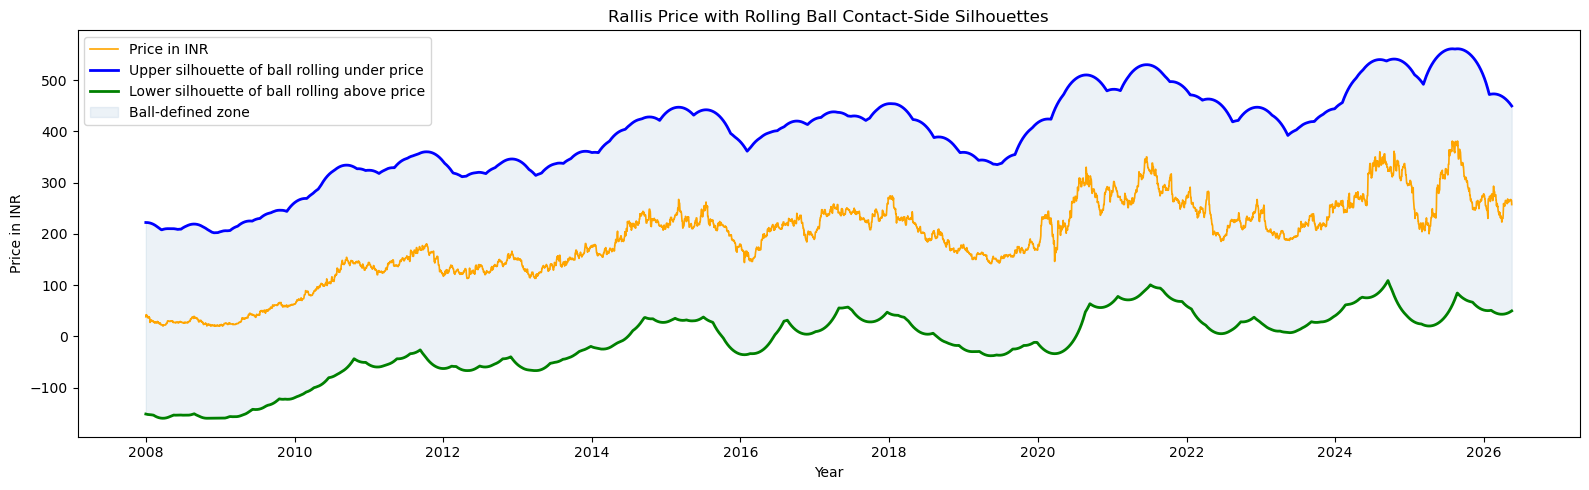

In [249]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import grey_dilation, grey_erosion


def build_ball_arc(circle_radius_days: int) -> np.ndarray:
    """
    Build the upper half of a 1D ball profile.

    For offsets u in [-r, r]:
        arc(u) = sqrt(r^2 - u^2)

    This returns a non-flat structuring element that represents
    the visible arc of the rolling ball.
    """
    offsets = np.arange(-circle_radius_days, circle_radius_days + 1)
    ball_arc = np.sqrt(
        np.maximum(0.0, circle_radius_days ** 2 - offsets ** 2)
    )
    return ball_arc.astype(float)


def upper_silhouette_of_ball_rolling_under_price(
    price_series: np.ndarray,
    circle_radius_days: int,
) -> np.ndarray:
    """
    Upper silhouette of a ball rolling under the price.

    Dilation with the ball arc gives:
        max(price[x - u] + arc[u])

    This traces the top edge of all ball placements that stay under
    the price series in the discrete morphological sense.
    """
    ball_arc = build_ball_arc(circle_radius_days)
    upper_silhouette = grey_dilation(
        price_series,
        structure=ball_arc,
        mode='reflect',
    )
    return upper_silhouette


def lower_silhouette_of_ball_rolling_above_price(
    price_series: np.ndarray,
    circle_radius_days: int,
) -> np.ndarray:
    """
    Lower silhouette of a ball rolling above the price.

    Erosion with the ball arc gives:
        min(price[x - u] - arc[u])

    This traces the bottom edge of all ball placements that stay above
    the price series in the discrete morphological sense.
    """
    ball_arc = build_ball_arc(circle_radius_days)
    lower_silhouette = grey_erosion(
        price_series,
        structure=ball_arc,
        mode='reflect',
    )
    return lower_silhouette


# ----- 1) Prepare data -----
df_inr_ts = df_inr.copy()
df_inr_ts = df_inr_ts[['date', 'price_inr']].copy()
df_inr_ts['date'] = pd.to_datetime(df_inr_ts['date'])
df_inr_ts = df_inr_ts.sort_values('date').reset_index(drop=True)

price_series = df_inr_ts['price_inr'].to_numpy(dtype=float)


# ----- 2) Choose radius -----
# Question:
# Do you want to start with 60, 90, or 180?
# 90 is a reasonable first trial on daily-filled data.
circle_radius_days = 180


# ----- 3) Compute the two silhouettes you asked for -----
df_inr_ts['upper_ball_under_price'] = (
    upper_silhouette_of_ball_rolling_under_price(
        price_series=price_series,
        circle_radius_days=circle_radius_days,
    )
)

df_inr_ts['lower_ball_above_price'] = (
    lower_silhouette_of_ball_rolling_above_price(
        price_series=price_series,
        circle_radius_days=circle_radius_days,
    )
)


# ----- 4) Plot -----
plt.figure(figsize=(16, 5))

plt.plot(
    df_inr_ts['date'],
    df_inr_ts['price_inr'],
    label='Price in INR',
    color='orange',
    linewidth=1.2,
)

plt.plot(
    df_inr_ts['date'],
    df_inr_ts['upper_ball_under_price'],
    label='Upper silhouette of ball rolling under price',
    color='blue',
    linewidth=2,
)

plt.plot(
    df_inr_ts['date'],
    df_inr_ts['lower_ball_above_price'],
    label='Lower silhouette of ball rolling above price',
    color='green',
    linewidth=2,
)

plt.fill_between(
    df_inr_ts['date'],
    df_inr_ts['lower_ball_above_price'],
    df_inr_ts['upper_ball_under_price'],
    color='steelblue',
    alpha=0.10,
    label='Ball-defined zone',
)

plt.xlabel('Year')
plt.ylabel('Price in INR')
plt.title('Rallis Price with Rolling Ball Contact-Side Silhouettes')
plt.legend()
plt.tight_layout()
plt.show()

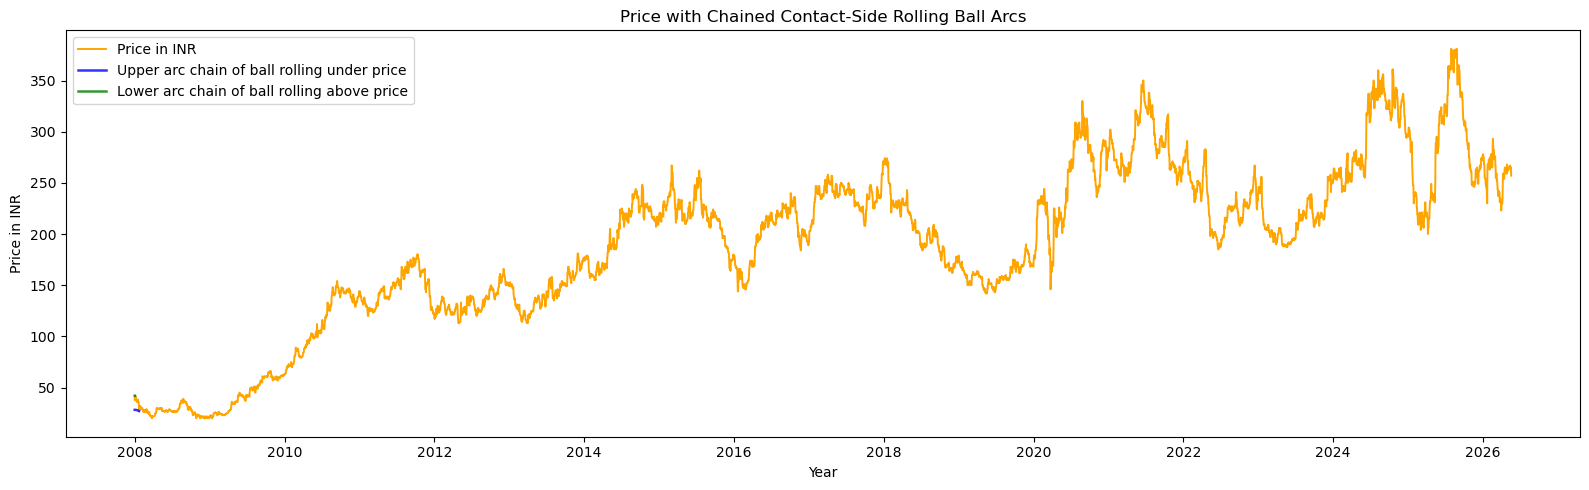

In [257]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def build_ball_arc(circle_radius_days: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Return integer offsets and circular arc heights.
    """
    offsets = np.arange(-circle_radius_days, circle_radius_days + 1)
    arc_height = np.sqrt(
        np.maximum(0.0, circle_radius_days ** 2 - offsets ** 2)
    )
    return offsets, arc_height


def compute_ball_center_under_price(
    price_series: np.ndarray,
    circle_radius_days: int,
) -> np.ndarray:
    """
    For each index i, compute the highest ball center such that
    the upper arc of the ball stays under the price series.
    """
    offsets, arc_height = build_ball_arc(circle_radius_days)
    point_count = len(price_series)
    center_under_price = np.full(point_count, np.nan, dtype=float)

    for center_index in range(point_count):
        allowed_center_values = []

        for offset, arc_value in zip(offsets, arc_height):
            price_index = center_index + offset

            if 0 <= price_index < point_count:
                allowed_center_values.append(
                    price_series[price_index] - arc_value
                )

        center_under_price[center_index] = min(allowed_center_values)

    return center_under_price


def compute_ball_center_above_price(
    price_series: np.ndarray,
    circle_radius_days: int,
) -> np.ndarray:
    """
    For each index i, compute the lowest ball center such that
    the lower arc of the ball stays above the price series.
    """
    offsets, arc_height = build_ball_arc(circle_radius_days)
    point_count = len(price_series)
    center_above_price = np.full(point_count, np.nan, dtype=float)

    for center_index in range(point_count):
        allowed_center_values = []

        for offset, arc_value in zip(offsets, arc_height):
            price_index = center_index + offset

            if 0 <= price_index < point_count:
                allowed_center_values.append(
                    price_series[price_index] + arc_value
                )

        center_above_price[center_index] = max(allowed_center_values)

    return center_above_price

def find_right_side_touch_indices(
    price_series: np.ndarray,
    center_value: float,
    center_index: int,
    circle_radius_days: int,
    draw_upper_arc: bool,
    touch_tolerance: float,
) -> list[int]:
    """
    Find all right-side touch points for the arc defined by one center.

    We only look to the right of the current center index.
    """
    offsets, arc_height = build_ball_arc(circle_radius_days)
    right_side_touch_indices: list[int] = []

    for offset, arc_value in zip(offsets, arc_height):
        if offset <= 0:
            continue

        curve_index = center_index + offset

        if curve_index >= len(price_series):
            continue

        if draw_upper_arc:
            arc_y_value = center_value + arc_value
        else:
            arc_y_value = center_value - arc_value

        if abs(price_series[curve_index] - arc_y_value) <= touch_tolerance:
            right_side_touch_indices.append(curve_index)

    return right_side_touch_indices


def build_chained_arc_segments(
    price_series: np.ndarray,
    center_values: np.ndarray,
    circle_radius_days: int,
    draw_upper_arc: bool,
    start_index: int,
    touch_tolerance: float,
    use_last_touch: bool,
) -> list[dict]:
    """
    Build a chained sequence of arcs.

    Each arc starts from one center index and jumps to a later touch point
    found on that same arc.
    """
    offsets, arc_height = build_ball_arc(circle_radius_days)
    arc_segments: list[dict] = []

    current_index = start_index
    visited_indices: set[int] = set()

    while current_index < len(price_series):
        if current_index in visited_indices:
            break

        visited_indices.add(current_index)

        center_value = center_values[current_index]

        if np.isnan(center_value):
            break

        touch_indices = find_right_side_touch_indices(
            price_series=price_series,
            center_value=center_value,
            center_index=current_index,
            circle_radius_days=circle_radius_days,
            draw_upper_arc=draw_upper_arc,
            touch_tolerance=touch_tolerance,
        )

        if not touch_indices:
            break

        if use_last_touch:
            next_index = touch_indices[-1]
        else:
            next_index = touch_indices[0]

        valid_indices = []
        arc_y_values = []

        for offset, arc_value in zip(offsets, arc_height):
            curve_index = current_index + offset

            if current_index <= curve_index <= next_index:
                if 0 <= curve_index < len(price_series):
                    valid_indices.append(curve_index)

                    if draw_upper_arc:
                        arc_y_values.append(center_value + arc_value)
                    else:
                        arc_y_values.append(center_value - arc_value)

        if len(valid_indices) >= 2:
            arc_segments.append(
                {
                    'start_index': current_index,
                    'end_index': next_index,
                    'curve_indices': valid_indices,
                    'curve_y_values': arc_y_values,
                }
            )

        current_index = next_index

    return arc_segments


def plot_chained_ball_arcs(
    date_values: pd.Series,
    price_series: np.ndarray,
    center_values: np.ndarray,
    circle_radius_days: int,
    line_color: str,
    draw_upper_arc: bool,
    alpha: float,
    linewidth: float,
    label: str,
    start_index: int,
    touch_tolerance: float,
    use_last_touch: bool,
) -> None:
    """
    Plot arcs in a chained fashion:
    current arc -> next touch -> next arc -> next touch -> ...
    """
    arc_segments = build_chained_arc_segments(
        price_series=price_series,
        center_values=center_values,
        circle_radius_days=circle_radius_days,
        draw_upper_arc=draw_upper_arc,
        start_index=start_index,
        touch_tolerance=touch_tolerance,
        use_last_touch=use_last_touch,
    )

    first_label_used = False

    for arc_segment in arc_segments:
        curve_dates = date_values.iloc[arc_segment['curve_indices']]

        plt.plot(
            curve_dates,
            arc_segment['curve_y_values'],
            color=line_color,
            alpha=alpha,
            linewidth=linewidth,
            label=label if not first_label_used else None,
        )
        first_label_used = True



# ----- 1) Prepare data -----
df_inr_ts = df_inr.copy()
df_inr_ts = df_inr_ts[['date', 'price_inr']].copy()
df_inr_ts['date'] = pd.to_datetime(df_inr_ts['date'])
df_inr_ts = df_inr_ts.sort_values('date').reset_index(drop=True)

price_series = df_inr_ts['price_inr'].to_numpy(dtype=float)


# ----- 2) Parameters -----
circle_radius_days = 180

# Question:
# How dense should the arc drawing be?
# Good first try: every 30th day.
arc_step = 90


# ----- 3) Compute ball centers -----
center_under_price = compute_ball_center_under_price(
    price_series=price_series,
    circle_radius_days=circle_radius_days,
)

center_above_price = compute_ball_center_above_price(
    price_series=price_series,
    circle_radius_days=circle_radius_days,
)


# ----- 4) Plot -----
plt.figure(figsize=(16, 5))

plt.plot(
    df_inr_ts['date'],
    df_inr_ts['price_inr'],
    label='Price in INR',
    color='orange',
    linewidth=1.4,
)

touch_tolerance = 1e-6

plot_chained_ball_arcs(
    date_values=df_inr_ts['date'],
    price_series=price_series,
    center_values=center_under_price,
    circle_radius_days=circle_radius_days,
    line_color='blue',
    draw_upper_arc=True,
    alpha=0.8,
    linewidth=1.8,
    label='Upper arc chain of ball rolling under price',
    start_index=0,
    touch_tolerance=touch_tolerance,
    use_last_touch=True,
)

plot_chained_ball_arcs(
    date_values=df_inr_ts['date'],
    price_series=price_series,
    center_values=center_above_price,
    circle_radius_days=circle_radius_days,
    line_color='green',
    draw_upper_arc=False,
    alpha=0.8,
    linewidth=1.8,
    label='Lower arc chain of ball rolling above price',
    start_index=0,
    touch_tolerance=touch_tolerance,
    use_last_touch=True,
)

plt.xlabel('Year')
plt.ylabel('Price in INR')
plt.title('Price with Chained Contact-Side Rolling Ball Arcs')
plt.legend()
plt.tight_layout()
plt.show()